In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [ ]:
samples = np.load(f"../../../../output/age_depth_unified_temp/samples_{config_str}.npy")
energy_values = np.load(f"../../../../output/age_depth_unified_temp/energy_values_{config_str}.npy")
bias_values = np.load(f"../../../../output/age_depth_unified_temp/bias_values_{config_str}.npy")
resampled_samples = np.load(f"../../../../output/age_depth_unified_temp/resampsamp_{config_str}.npy")

In [4]:
print(np.shape(resampled_samples))

(4, 999990, 10)


In [5]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [6]:
print(energy_values)

[[-280.72785429 -364.72700512 -361.67496246 ...   70.70867858
    71.55528831   69.89089896]
 [-317.53613804 -322.53874426 -318.68884431 ...  110.74812402
   112.67916661  112.3957107 ]
 [-124.17971138 -204.17670534 -291.03745433 ...   76.95031522
    73.03624966   71.38127829]
 [ -45.55101075 -194.73888928 -290.03205996 ...  123.53045835
   122.95661524  123.57955451]]


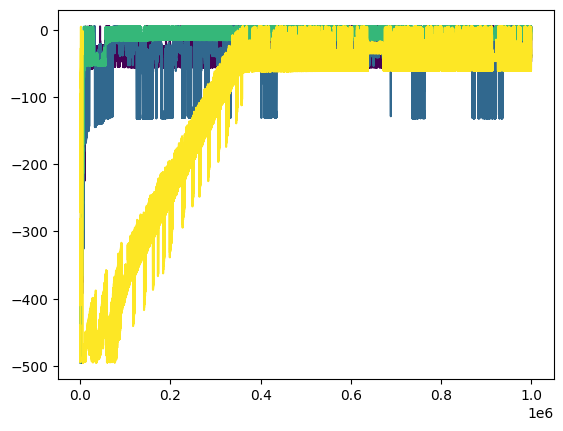

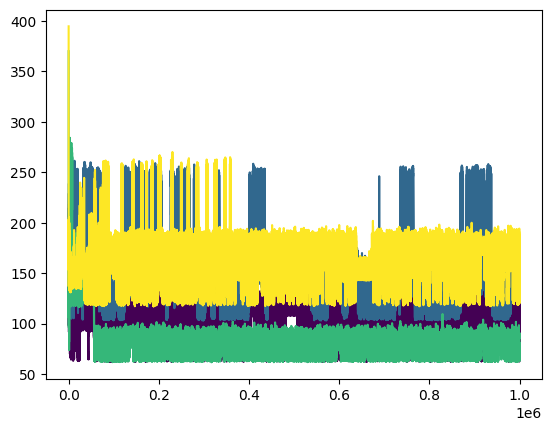

In [7]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:] - bias_values[i,:], color = colors[i])
plt.show()


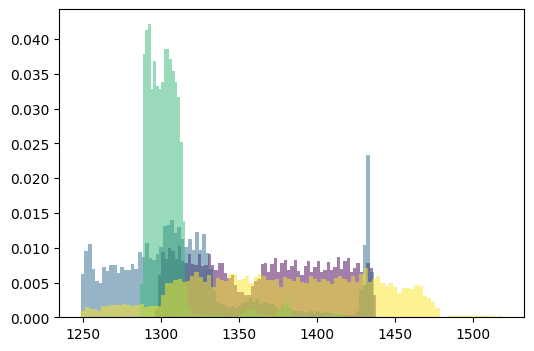

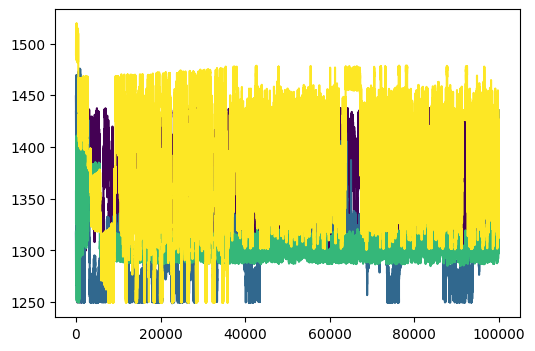

In [8]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, ::10], color = colors[i], label = f"chain {i}")
plt.show()

In [9]:
resampled_samples = resampled_samples[:,::100,:]

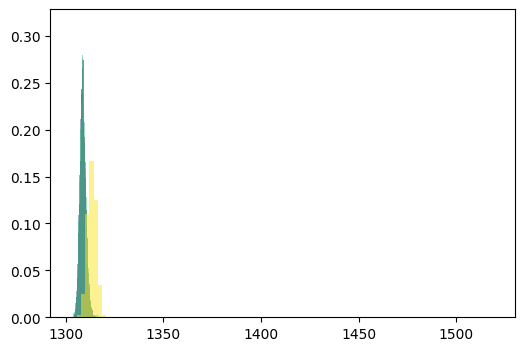

In [10]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

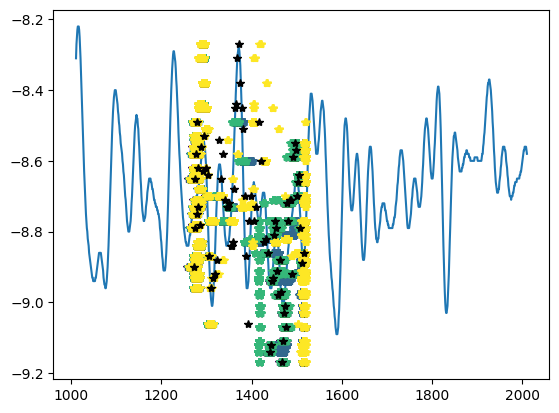

In [11]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [12]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]   5.19   4.94    0.00    11.33       2.44     0.00      6.03     83.48   
x[1]   6.27   5.55    0.01    13.47       2.63     0.03      6.03     82.47   
x[2]   4.52   3.40    0.01    10.06       1.47     0.19      5.99     50.71   
x[3]  12.91   8.98    0.02    26.23       4.38     2.16      4.86     24.86   
x[4]  76.13  14.89   61.63   101.78       7.36     3.58      5.38     25.14   
x[5]   9.78   2.13    6.39    13.99       0.74     0.36      9.19     27.35   
x[6]   4.76   1.56    1.69     7.60       0.24     0.02     41.23    119.71   
x[7]   1.22   1.00    0.01     2.79       0.01     0.05  37565.02  39628.89   
x[8]   0.87   0.67    0.01     2.05       0.00     0.01  39731.78  39232.01   
x[9]   2.45   1.77    0.04     5.67       0.01     0.01  39507.63  38186.32   

      r_hat  
x[0]   1.73  
x[1]   1.73  
x[2]   1.75  
x[3]   2.39  
x[4]   2.06  
x[5]   1.34  
x[6]   1.06  
x[7]   1.00  
x[8]

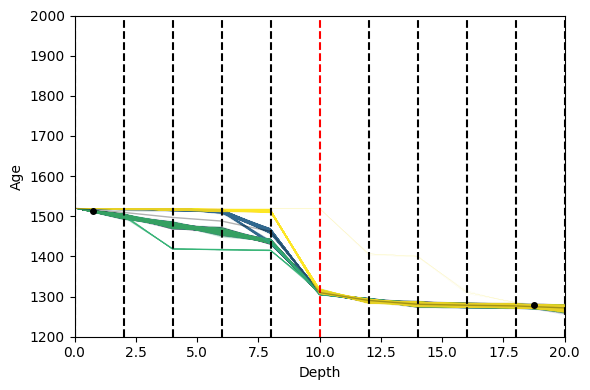

In [13]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    if i != config["pidx"]:
        ax.axvline(x=c, color='k', linestyle='--')
    else:
        ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()